# 13 — Inference: Continuous Learning Demo

End-to-end tour of the `inference` continuous-learning surface on a synthetic stream generated via `generate_patient` + `reward_oracle`. The centrepiece is **`LearningStream`** — the rich per-step event channel used for real-time observability.

### Sections
1. Setup
2. `update()` — the simple single-record surface
3. `LearningStream` — the rich per-step event (every one of the 31 fields on `LearningStepEvent`)
4. Real-time learning run with a BMI distribution shift:
   - step-by-step printed output
   - posterior means diverging over time
   - posterior uncertainty shrinking over time
   - rolling explore-vs-exploit window
   - cumulative reward / regret / running accuracy
   - drift z-scores + alerts firing after the shift
   - backbone-health timeline (retrains, replay buffer, noise variance)
5. SSE frame preview — what an HTTP streaming client would receive

## 1. Setup

In [17]:
from pathlib import Path
import os, sys
repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from src.data_generator import generate_patient, reward_oracle, TREATMENTS
from inference import (
    InferenceEngine, InferenceConfig,
    LearningStream, LearningStepEvent,
)


In [18]:
cfg = InferenceConfig.load(
    online_retraining=True,
    replay_buffer_size=2000,
    retrain_every=200,
    min_buffer_for_retrain=200,
    minibatch_size=64,
    drift_enabled=True,
    drift_baseline_size=200,
    drift_window_size=200,
    drift_threshold_z=2.5,
    n_confidence_draws=64,
    device='cpu',
)
engine = InferenceEngine.from_config(cfg)
engine.snapshot()

2026-04-16 09:13:19.576 | INFO     | inference._internal.feature_engineering:load:310 - FeaturePipeline loaded from models\feature_pipeline.joblib: 25 features, scale=True
2026-04-16 09:13:19.588 | INFO     | inference._internal.neural_bandit:__init__:158 - NeuralThompson initialized: input=25, hidden=[128, 64], device=cpu
2026-04-16 09:13:19.597 | INFO     | inference._internal.neural_bandit:load:1000 - Loaded NeuralThompson (with posterior) from models\neural_thompson.pt
2026-04-16 09:13:19.599 | INFO     | inference._internal.neural_bandit:enable_online_retraining:831 - Online retraining enabled: buffer=2000, retrain_every=200, minibatch=64
2026-04-16 09:13:19.599 | INFO     | inference._internal.explainability:__init__:557 - ExplainabilityExtractor initialized — confidence method: posterior sampling (64 draws), attribution=on, fairness=omitted


{'ready': True,
 'n_updates': 0,
 'model_path': 'models\\neural_thompson.pt',
 'pipeline_path': 'models\\feature_pipeline.joblib',
 'model_version': 'c9aaa56b2514',
 'pipeline_version': '96cb7eab5fe6',
 'feature_names': ['age',
  'bmi',
  'hba1c_baseline',
  'egfr',
  'diabetes_duration',
  'fasting_glucose',
  'c_peptide',
  'bp_systolic',
  'ldl',
  'hdl',
  'triglycerides',
  'alt',
  'cvd',
  'ckd',
  'nafld',
  'hypertension',
  'age_x_ckd',
  'bmi_x_nafld',
  'cvd_x_egfr',
  'cpeptide_x_hba1c',
  'duration_x_hba1c',
  'fg_x_bmi',
  'tg_hdl_ratio',
  'renal_risk',
  'severity_score'],
 'llm_enabled': False,
 'llm_provider': 'none',
 'online_retraining': True,
 'drift_enabled': True,
 'n_confidence_draws': 64,
 'attribution_enabled': True}

In [19]:
rng = np.random.RandomState(0)

def sample_patient(rng, patient_id=None):
    ctx = generate_patient(rng)
    if patient_id is not None:
        ctx['patient_id'] = patient_id
    return ctx

def oracle_vector(ctx, noise=True):
    """Per-arm counterfactual rewards in canonical treatment order."""
    return np.array(
        [reward_oracle(ctx, t, noise=noise) for t in TREATMENTS],
        dtype=float,
    )


## 2. `update()` — the simple single-record surface

The familiar ack-based API: submit `(patient, action, reward)`, get back a `LearningAck`. Use this when you already know the action and the observed reward.

In [20]:
ctx = sample_patient(rng, patient_id='SINGLE-001')
action = int(rng.randint(0, len(TREATMENTS)))
reward = float(reward_oracle(ctx, TREATMENTS[action], noise=True))
ack = engine.update({'patient': ctx, 'action': action, 'reward': reward})
print(f'accepted={ack.accepted} n={ack.n_updates_so_far} '
      f'posterior_updated={ack.posterior_updated} '
      f'retrain={ack.backbone_retrained}')

accepted=True n=1 posterior_updated=True retrain=False


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. `LearningStream` — the rich per-step event

`LearningStream` drives Thompson sampling itself (you supply only the patient and a per-arm oracle reward vector), applies the online update, and emits a `LearningStepEvent` capturing the **full** internal state that drove the decision:

| Group | Fields |
|---|---|
| core decision | `step`, `selectedIdx`, `posteriorMeanArgmax`, `explored`, `thompsonSamples`, `observedReward`, `oracleOptimalIdx`, `oracleOptimalReward`, `regret` |
| posterior state | `posteriorMeans`, `posteriorUncertainty`, `winRates`, `confidencePct`, `confidenceLabel`, `meanGap`, `nUpdatesPerArm` |
| running aggregates | `cumulativeReward`, `cumulativeRegret`, `runningAccuracy`, `runningMeanRewardPerArm`, `bestTreatmentIdx`, `phase` |
| backbone health | `retrainFired`, `noiseVariance`, `replayBufferSize` |
| drift signals | `contextNorm`, `driftAlerts`, `driftStreams` |
| patient context | `patientId`, `patientFeatures`, `safetyStatus` |

`thompsonSamples` is *causally correct* — it's the exact per-arm draw (from the same `phi`, `mu`, `A_inv`, `noise_variance`) that produced `selectedIdx`.

In [21]:
# One event — every field on LearningStepEvent
preview_rng = np.random.default_rng(42)
with engine.learning_stream(total_steps=5, rng=preview_rng) as stream:
    ctx = sample_patient(rng, patient_id='DEMO-PREVIEW')
    event = stream.step(ctx, oracle_vector(ctx))

payload = event.model_dump()
print(f'{len(payload)} fields on LearningStepEvent\n')
for k, v in payload.items():
    if isinstance(v, dict):
        inner = ', '.join(f"{ik}={iv!r}" for ik, iv in v.items())
        print(f'  {k}: {{{inner}}}')
    else:
        print(f'  {k}: {v!r}')

31 fields on LearningStepEvent

  step: 1
  selectedIdx: 2
  posteriorMeanArgmax: 2
  explored: False
  thompsonSamples: {Metformin=-0.05419842999779264, GLP-1=1.4337912484696813, SGLT-2=1.7007344507340119, DPP-4=1.5194527130167375, Insulin=-0.20493438105281994}
  observedReward: 1.5286180690333975
  oracleOptimalIdx: 1
  oracleOptimalReward: 1.642679979762029
  regret: 0.11406191072863159
  posteriorMeans: {Metformin=-0.07483790166692773, GLP-1=1.506752199962822, SGLT-2=1.6434376883649955, DPP-4=1.4224084179478975, Insulin=-0.03205133708003338}
  posteriorUncertainty: {Metformin=0.018351161111326893, GLP-1=0.019687363730687128, SGLT-2=0.020916560416075564, DPP-4=0.04258166557362576, Insulin=0.031407588186319536}
  winRates: {Metformin=0.0, GLP-1=0.109, SGLT-2=0.859, DPP-4=0.031, Insulin=0.0}
  confidencePct: 86
  confidenceLabel: 'HIGH'
  meanGap: 0.14
  nUpdatesPerArm: {Metformin=0, GLP-1=0, SGLT-2=1, DPP-4=0, Insulin=0}
  cumulativeReward: 1.5286180690333975
  cumulativeRegret: 0.11

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### 3.1 Compact console line

`event.to_console_line()` is a one-line human-readable summary. Useful for dev loops, log sinks, or a CLI dashboard.

In [22]:
print(event.to_console_line())

[Early] step    1 | exploit -> SGLT-2    -- | r=+1.529 reg=+0.114 cumReg=  +0.11 acc= 0.00% conf= 86% (HIGH    ) safety=WARNING


## 4. Real-time learning run with a BMI distribution shift

Stream 600 synthetic patients with the display updating as each patient arrives — `clear_output(wait=True)` for a live tail of recent console lines, plus three charts (cumulative reward, cumulative regret, posterior means) that redraw every 10 steps. A BMI shift is injected at step 300 to trigger the drift monitor.

The collected `events` list feeds the post-loop sections 4.1–4.7 that visualise each field group in full.

[Late ] step  589 | EXPLORE -> DPP-4     -- | r=+0.785 reg=+0.660 cumReg=+134.70 acc=64.18% conf= 55% (LOW     ) safety=WARNING
[Late ] step  590 | exploit -> DPP-4     OK | r=+0.763 reg=+0.000 cumReg=+134.70 acc=64.24% conf= 61% (MODERATE) safety=CLEAR
[Late ] step  591 | EXPLORE -> Insulin   OK | r=+2.155 reg=+0.000 cumReg=+134.70 acc=64.30% conf= 75% (MODERATE) safety=WARNING
[Late ] step  592 | exploit -> GLP-1     OK | r=+1.639 reg=+0.000 cumReg=+134.70 acc=64.36% conf= 97% (HIGH    ) safety=CLEAR
[Late ] step  593 | EXPLORE -> GLP-1     -- | r=+0.000 reg=+1.427 cumReg=+136.13 acc=64.25% conf= 42% (LOW     ) safety=CLEAR
[Late ] step  594 | EXPLORE -> SGLT-2    -- | r=+1.166 reg=+0.066 cumReg=+136.19 acc=64.14% conf= 45% (LOW     ) safety=CLEAR
[Late ] step  595 | exploit -> SGLT-2    OK | r=+1.833 reg=+0.000 cumReg=+136.19 acc=64.20% conf= 70% (MODERATE) safety=CLEAR
[Late ] step  596 | EXPLORE -> DPP-4     -- | r=+1.497 reg=+0.209 cumReg=+136.40 acc=64.09% conf= 41% (LOW     ) s

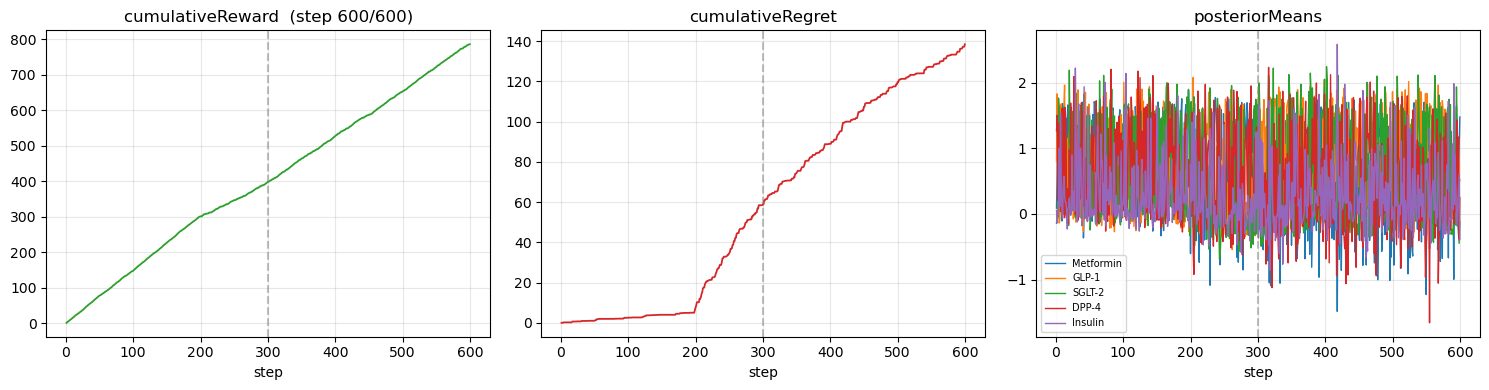


Final snapshot: {'steps': 600, 'cumulative_reward': 785.2931868548465, 'cumulative_regret': 138.40253728299024, 'running_accuracy': 0.64, 'per_arm_pulls': {'Metformin': 129, 'GLP-1': 163, 'SGLT-2': 135, 'DPP-4': 104, 'Insulin': 69}}


In [23]:
N = 600
shift_start = 300
redraw_every = 10
tail_lines = 12          # recent console lines kept on screen

events: list[LearningStepEvent] = []
recent = deque(maxlen=tail_lines)
stream_rng = np.random.default_rng(7)

plt.ioff()
fig_live, axes_live = plt.subplots(1, 3, figsize=(15, 4))

def _redraw(axes, events, shift_start, N, step_now):
    steps_so_far = np.array([e.step for e in events])
    cum_r = np.array([e.cumulativeReward for e in events])
    cum_reg = np.array([e.cumulativeRegret for e in events])
    pmeans_live = {t: np.array([e.posteriorMeans[t] for e in events])
                   for t in TREATMENTS}
    for ax in axes: ax.clear()
    axes[0].plot(steps_so_far, cum_r, color='#2ca02c', linewidth=1.3)
    axes[0].set_title(f'cumulativeReward  (step {step_now}/{N})')
    axes[0].set_xlabel('step'); axes[0].grid(alpha=0.3)
    axes[1].plot(steps_so_far, cum_reg, color='#d62728', linewidth=1.3)
    axes[1].set_title('cumulativeRegret')
    axes[1].set_xlabel('step'); axes[1].grid(alpha=0.3)
    for t in TREATMENTS:
        axes[2].plot(steps_so_far, pmeans_live[t], label=t, linewidth=1.0)
    axes[2].set_title('posteriorMeans')
    axes[2].set_xlabel('step')
    axes[2].legend(loc='best', fontsize=7); axes[2].grid(alpha=0.3)
    for ax in axes:
        ax.axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
    fig_live.tight_layout()

try:
    with engine.learning_stream(total_steps=N, rng=stream_rng) as stream:
        for i in range(N):
            ctx = sample_patient(rng)
            if i >= shift_start:
                ctx['bmi'] = min(float(ctx['bmi']) + 6.0, 79.0)
            event = stream.step(ctx, oracle_vector(ctx))
            events.append(event)
            recent.append(event.to_console_line())

            if (i + 1) % redraw_every == 0 or i == N - 1:
                _redraw(axes_live, events, shift_start, N, i + 1)

            clear_output(wait=True)
            for line in recent:
                print(line)
            display(fig_live)
finally:
    plt.ion()
    plt.close(fig_live)

snap = stream.snapshot()
print()
print(f'Final snapshot: {snap}')

### 4.1 Posterior means diverging over time

`posteriorMeans` is the per-arm mean HbA1c-reduction estimate after each update. The five curves should fan apart as the model learns which treatments work.

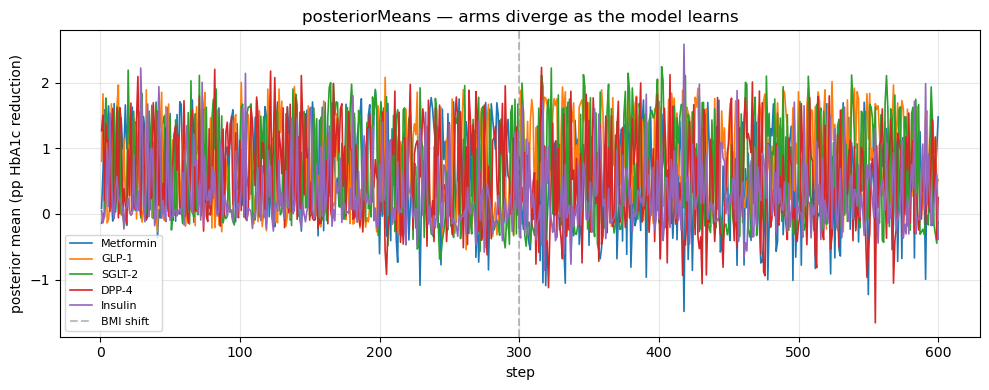

In [24]:
steps = np.array([e.step for e in events])
pmeans = {t: np.array([e.posteriorMeans[t] for e in events]) for t in TREATMENTS}

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for t in TREATMENTS:
    ax.plot(steps, pmeans[t], label=t, linewidth=1.2)
ax.axvline(shift_start, color='grey', linestyle='--', alpha=0.5, label='BMI shift')
ax.set_xlabel('step')
ax.set_ylabel('posterior mean (pp HbA1c reduction)')
ax.set_title('posteriorMeans — arms diverge as the model learns')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Posterior uncertainty shrinking over time

`posteriorUncertainty` is `φᵀ A⁻¹ φ` per arm — the last-layer Bayesian-regression variance proxy. For arms that get pulled, it shrinks; arms that are never chosen stay at the prior.

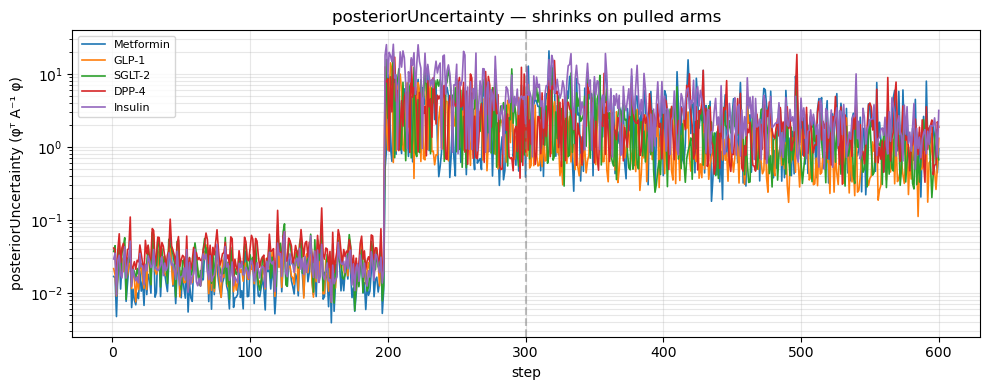

In [25]:
punc = {t: np.array([e.posteriorUncertainty[t] for e in events]) for t in TREATMENTS}

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for t in TREATMENTS:
    ax.plot(steps, punc[t], label=t, linewidth=1.2)
ax.axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('step')
ax.set_ylabel('posteriorUncertainty (φᵀ A⁻¹ φ)')
ax.set_title('posteriorUncertainty — shrinks on pulled arms')
ax.set_yscale('log')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### 4.3 Rolling explore-vs-exploit window

`event.explored` is `True` when the Thompson draw picked a different arm than the posterior-mean argmax — i.e. real exploration, not exploit. A rolling mean over a 50-step window shows how exploration naturally tapers as the posterior sharpens.

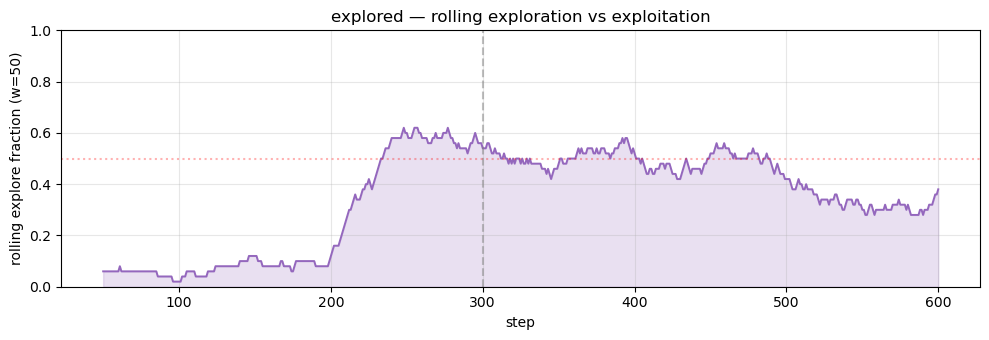

total explored: 204 / 600 (34.0%)


In [26]:
window = 50
explored = np.array([1.0 if e.explored else 0.0 for e in events])
roll = np.convolve(explored, np.ones(window) / window, mode='valid')
roll_steps = steps[window - 1:]

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(roll_steps, roll, color='#9467bd', linewidth=1.4)
ax.axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
ax.axhline(0.5, color='red', linestyle=':', alpha=0.3, label='50% band')
ax.fill_between(roll_steps, roll, alpha=0.2, color='#9467bd')
ax.set_ylim(0, 1)
ax.set_xlabel('step')
ax.set_ylabel(f'rolling explore fraction (w={window})')
ax.set_title('explored — rolling exploration vs exploitation')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'total explored: {int(explored.sum())} / {len(explored)} '
      f'({explored.mean():.1%})')

### 4.4 Running aggregates — cumulative reward, regret, accuracy

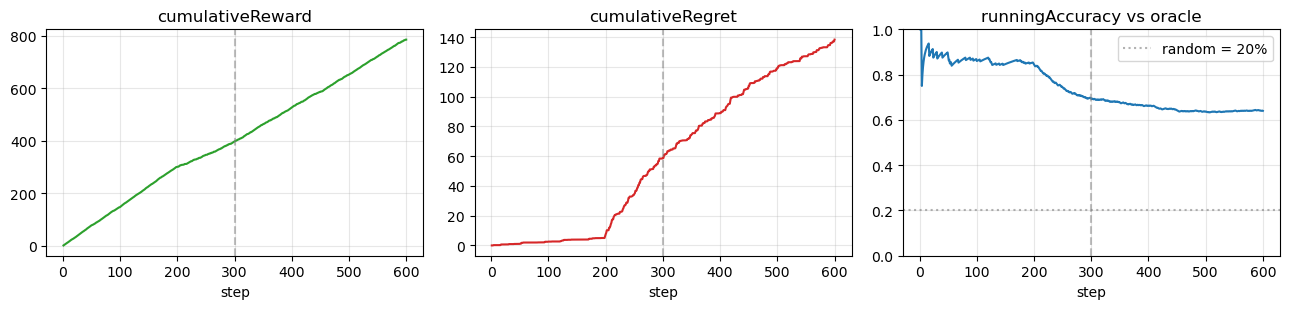

In [27]:
cum_r = np.array([e.cumulativeReward for e in events])
cum_reg = np.array([e.cumulativeRegret for e in events])
acc = np.array([e.runningAccuracy for e in events])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(steps, cum_r, color='#2ca02c')
axes[0].set_title('cumulativeReward')
axes[0].set_xlabel('step'); axes[0].grid(alpha=0.3)
axes[1].plot(steps, cum_reg, color='#d62728')
axes[1].set_title('cumulativeRegret')
axes[1].set_xlabel('step'); axes[1].grid(alpha=0.3)
axes[2].plot(steps, acc, color='#1f77b4')
axes[2].axhline(1 / len(TREATMENTS), color='grey', linestyle=':', alpha=0.6,
                label=f'random = {1/len(TREATMENTS):.0%}')
axes[2].set_ylim(0, 1)
axes[2].set_title('runningAccuracy vs oracle')
axes[2].set_xlabel('step'); axes[2].legend(); axes[2].grid(alpha=0.3)
for ax in axes:
    ax.axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.5 Drift signals — z-scores + alerts after the BMI shift

`driftStreams` exposes the rolling-window z-score for each monitored signal (context-norm, action, reward) vs the baseline captured from the first `drift_baseline_size` observations. The shaded region marks the shifted BMI regime, and orange ticks show every step where a `DriftAlert` fired.

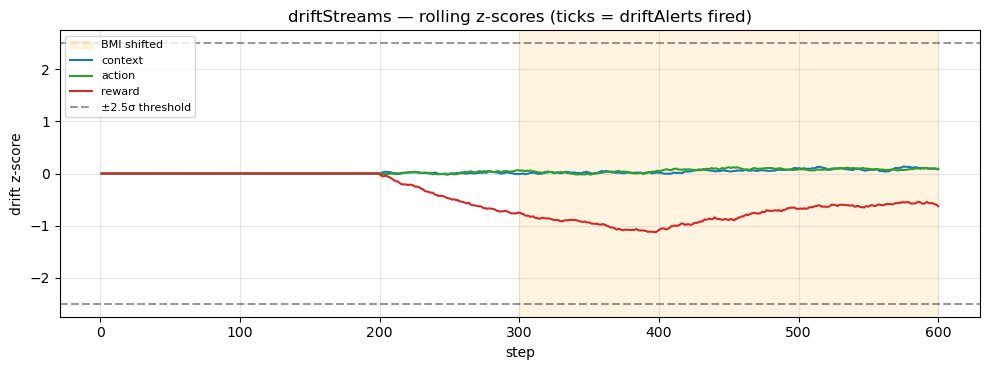

drift alerts fired on 0 steps


In [28]:
drift_ctx = np.array([e.driftStreams.get('context', 0.0) for e in events])
drift_act = np.array([e.driftStreams.get('action', 0.0) for e in events])
drift_rew = np.array([e.driftStreams.get('reward', 0.0) for e in events])
alert_steps = [e.step for e in events if e.driftAlerts]

fig, ax = plt.subplots(1, 1, figsize=(10, 3.8))
ax.axvspan(shift_start, N, alpha=0.12, color='orange', label='BMI shifted')
ax.plot(steps, drift_ctx, label='context', color='#1f77b4')
ax.plot(steps, drift_act, label='action', color='#2ca02c')
ax.plot(steps, drift_rew, label='reward', color='#d62728')
for s in alert_steps:
    ax.axvline(s, color='#ff7f0e', alpha=0.25, linestyle=':')
ax.axhline(cfg.drift_threshold_z, color='black', linestyle='--', alpha=0.4,
           label=f'±{cfg.drift_threshold_z}σ threshold')
ax.axhline(-cfg.drift_threshold_z, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('step')
ax.set_ylabel('drift z-score')
ax.set_title('driftStreams — rolling z-scores (ticks = driftAlerts fired)')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'drift alerts fired on {len(alert_steps)} steps')

### 4.6 Backbone health — retrains, replay buffer, noise variance

`retrainFired` is `True` on steps where the shared backbone was retrained on the replay buffer (G-4). `replayBufferSize` grows up to the configured cap, and `noiseVariance` is the posterior noise parameter σ².

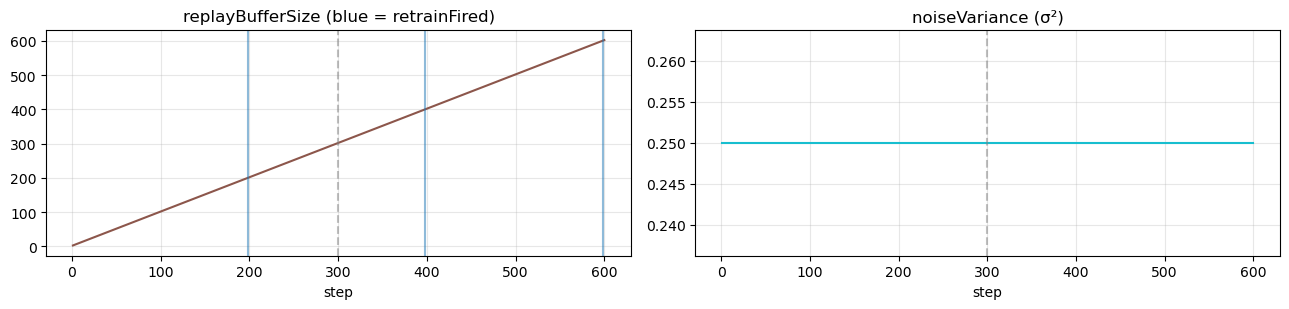

retrains fired: 3


In [29]:
replay = np.array([e.replayBufferSize for e in events])
noise_var = np.array([e.noiseVariance for e in events])
retrain_steps = [e.step for e in events if e.retrainFired]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(steps, replay, color='#8c564b')
for rs in retrain_steps:
    axes[0].axvline(rs, color='#1f77b4', alpha=0.5)
axes[0].axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
axes[0].set_title('replayBufferSize (blue = retrainFired)')
axes[0].set_xlabel('step'); axes[0].grid(alpha=0.3)

axes[1].plot(steps, noise_var, color='#17becf')
axes[1].axvline(shift_start, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('noiseVariance (σ²)')
axes[1].set_xlabel('step'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'retrains fired: {len(retrain_steps)}')

### 4.7 Per-arm pulls + running reward — where did the traffic go?

`nUpdatesPerArm` and `runningMeanRewardPerArm` track traffic allocation and realised performance per treatment.

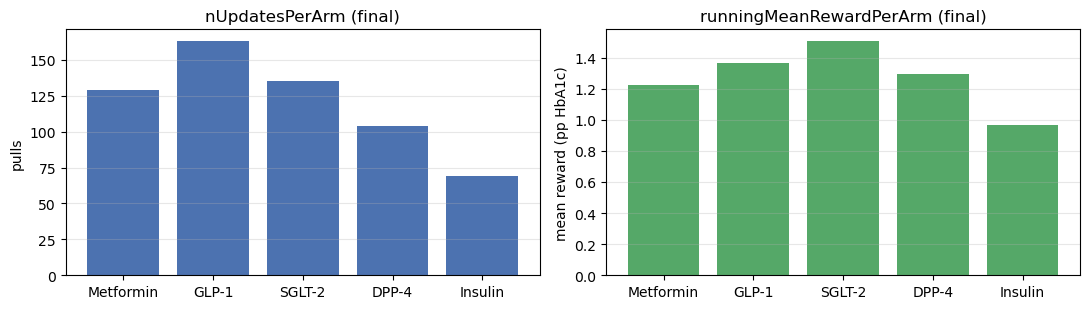

bestTreatmentIdx (last): 0 (Metformin)
confidencePct (last): 81% (MODERATE)
meanGap (last): 0.9600
phase (last): Late
safetyStatus (last): CLEAR


In [30]:
last = events[-1]
names = list(last.nUpdatesPerArm.keys())
pulls = [last.nUpdatesPerArm[t] for t in names]
mrew = [last.runningMeanRewardPerArm[t] for t in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(names, pulls, color='#4c72b0')
axes[0].set_title('nUpdatesPerArm (final)')
axes[0].set_ylabel('pulls')
axes[1].bar(names, mrew, color='#55a868')
axes[1].set_title('runningMeanRewardPerArm (final)')
axes[1].set_ylabel('mean reward (pp HbA1c)')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'bestTreatmentIdx (last): {last.bestTreatmentIdx} '
      f'({TREATMENTS[last.bestTreatmentIdx]})')
print(f'confidencePct (last): {last.confidencePct}% ({last.confidenceLabel})')
print(f'meanGap (last): {last.meanGap:.4f}')
print(f'phase (last): {last.phase}')
print(f'safetyStatus (last): {last.safetyStatus}')

## 5. SSE frame preview

`event.to_sse()` returns the exact bytes a browser `EventSource` would read off the wire. See `inference/examples/fastapi_app.py` for a runnable `/learn/stream/rich` endpoint wired to `engine.alearning_stream(...)`.

In [31]:
frame = events[-1].to_sse()
print(frame[:400].decode('utf-8'), '...' if len(frame) > 400 else '')

data: {"step":600,"selectedIdx":2,"posteriorMeanArgmax":0,"explored":true,"thompsonSamples":{"Metformin":0.7731962210282866,"GLP-1":0.24604239899992786,"SGLT-2":1.063514459172103,"DPP-4":-0.46924440614535223,"Insulin":-1.8812025560831676},"observedReward":0.0,"oracleOptimalIdx":0,"oracleOptimalReward":1.2445574572179703,"regret":1.2445574572179703,"posteriorMeans":{"Metformin":1.4782458163023864," ...


## 6. Final engine snapshot

In [32]:
engine.snapshot()

{'ready': True,
 'n_updates': 602,
 'model_path': 'models\\neural_thompson.pt',
 'pipeline_path': 'models\\feature_pipeline.joblib',
 'model_version': 'c9aaa56b2514',
 'pipeline_version': '96cb7eab5fe6',
 'feature_names': ['age',
  'bmi',
  'hba1c_baseline',
  'egfr',
  'diabetes_duration',
  'fasting_glucose',
  'c_peptide',
  'bp_systolic',
  'ldl',
  'hdl',
  'triglycerides',
  'alt',
  'cvd',
  'ckd',
  'nafld',
  'hypertension',
  'age_x_ckd',
  'bmi_x_nafld',
  'cvd_x_egfr',
  'cpeptide_x_hba1c',
  'duration_x_hba1c',
  'fg_x_bmi',
  'tg_hdl_ratio',
  'renal_risk',
  'severity_score'],
 'llm_enabled': False,
 'llm_provider': 'none',
 'online_retraining': True,
 'drift_enabled': True,
 'n_confidence_draws': 64,
 'attribution_enabled': True}

---

Done. `LearningStream` complements — does not replace — `update()` / `learning_session()`. Reach for it when you need real-time step-by-step visibility into the decision, posterior, aggregates, drift, and backbone health.